# ANN for regression
### Dataset name is "California Housing Prices"
### (https://www.kaggle.com/datasets/camnugent/california-housing-prices)
### The dataset is 20.6K rows, can be considered as a medium dataset. It contains 7 numeric columns, 2 columns with coordinates, and one column with categorical value - text values. The target variable is "median house value". 
#### Background: I worked with this dataset in "Introduction to ML course", where I created fore different Jupyter notebooks. I implemented Linear and Polynomial Regression models: two of them used the ocean_proximity column, and the other two used the coordinates. The result showed that Polynomial Regression models achieved better metrics overall. There was no significant difference between using ocean_proximity or the coordinates, even when I attempted to calculate the distance from the coastline more precisely. Was recomended to calculate distance to nearest big cities.
#### In this project I will keep both ocean_proximity column and coordinates because they capture different aspects of location, coordinates - very precise location and Ocean proximity - higher level geographic grouping. As it was recomended to calculate distance to nearest big cities and will train ANN with and without this additional column, and will compare metrics.

In [73]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics


import tensorflow as tf
import keras
from keras import layers

## Loading the dataset

In [74]:
# load data 
df = pd.read_csv("housing.csv")

In [75]:
# According to CharGPT is it enouth for small ANN model, good enough to learn basic patterns. 
len(df)

20640

In [76]:
# the dataset has 10 clolumns, and one "ocean_proximity" is categorical. I will need to encode it properly (one-hot encoding)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<Axes: >

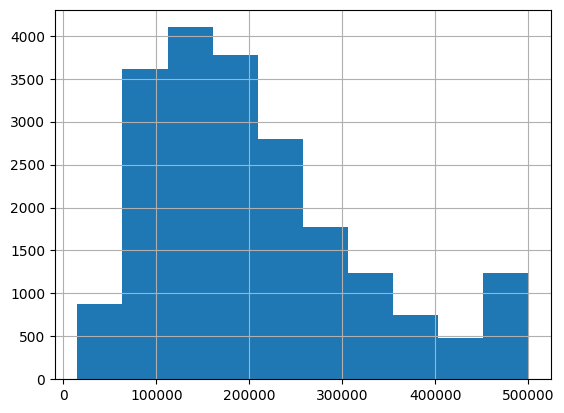

In [77]:
# this plot shows that the target variable is right-skewed, there's a smaller group of homes with very high price, this tail indicates high-value homes
# for now I will keep the outliers, but might consider removing or transforming them later
df['median_house_value'].hist()

In [78]:
# check if we have any missing values
df.isna().sum()

# we have missing values. I cannot fill them with median value as depends on how big a house is. I will drop them for now, not later will check how it will affect the results.

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [79]:
# dropping rows with missing values
df = df.dropna()

In [80]:
df.isna().sum()

# now we don't have any missing values

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [81]:
# check duplicates
int(df.duplicated().sum())

# no duplicates

0

## Handling the categorical variables

In [82]:
# "ocean_proximity" is nominal categorical variable, I will use one-hot encoding to convert it to numerical
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [83]:
# by using encoder we will add 5 new columns, but will remove one -  and the original one.
from sklearn.preprocessing import OneHotEncoder
variables = ['ocean_proximity']

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [84]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


In [85]:
# dropping the last variable:
df = df.drop("ocean_proximity_NEAR OCEAN", axis=1)

In [86]:
# let's check:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1


### Let's check the correlation between the features against each other and check distribution of support variables:

<Axes: >

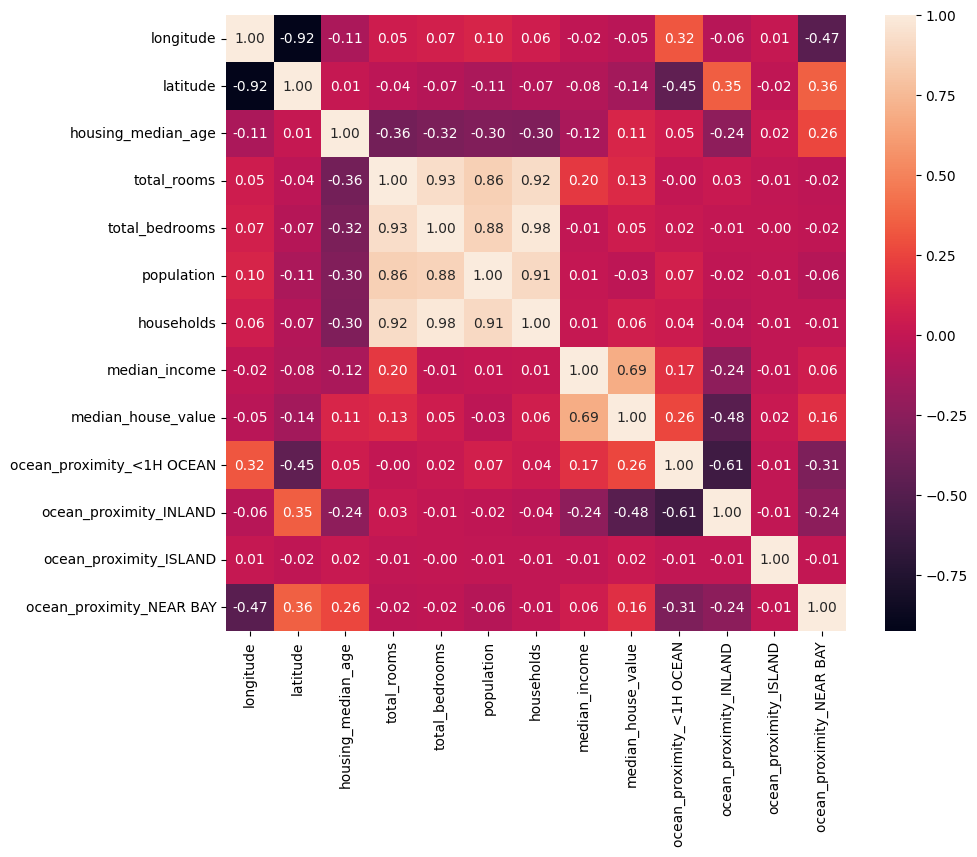

In [87]:
# it was difficult to see numbers, so we will increase the figure size:
plt.figure(figsize=(10, 8))

# on this correlation matrix we can see the most important supported variables:
# median_income. 
correlations = df.corr(numeric_only=True)
sns.heatmap(correlations, annot=True, fmt='.2f')

### Support variables based on correlations are: "median_income" and "ocean_proximity_<1H OCEAN" but the last has poor connection, just 0.26.

<Axes: xlabel='median_income', ylabel='Count'>

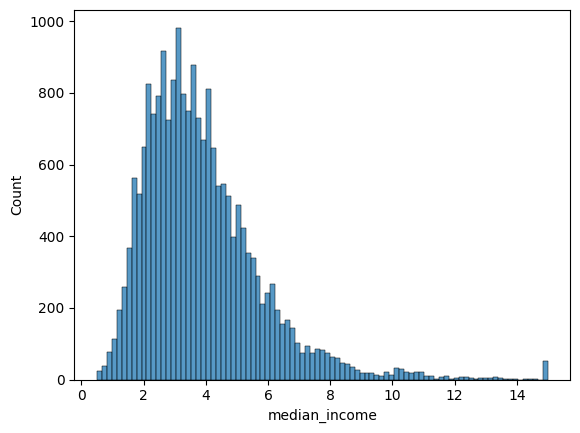

In [88]:
# let's check the distribution of median_income
sns.histplot(df['median_income'])

# So, it has veery loong tail. I will check first how it affects the model, and if needed I will transform it later.

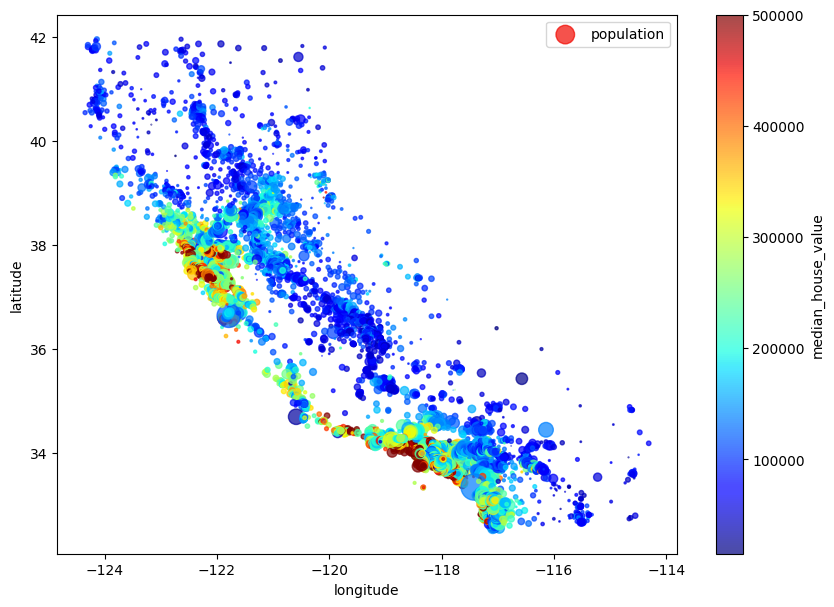

In [89]:
# let's check coordinates against the target variable:

df.plot(kind="scatter", x="longitude",y="latitude", c="median_house_value", cmap="jet", colorbar=True, legend=True, sharex=False, figsize=(10,7), s=df['population']/100, label="population", alpha=0.7)
plt.show()

# We can see that houses near ocean are the most expensive but there are some outliers,
# and we can spot two big cities Los Angeles and San Francisco, where expensive houses concentrate.
# I will create second Jupyter notebook, where I will add distances to these cities as new features.
# We can check if it will improve the model as it will give the model deeper understanding how prices of houses are formed.    


# Ref:https://medium.com/@basumatary18/implementing-linear-regression-on-california-housing-dataset-378e14e421b7#id_token=eyJhbGciOiJSUzI1NiIsImtpZCI6ImZhMDcyZjc1Nzg0NjQyNjE1MDg3YzcxODJjMTAxMzQxZTE4ZjdhM2EiLCJ0eXAiOiJKV1QifQ.eyJpc3MiOiJodHRwczovL2FjY291bnRzLmdvb2dsZS5jb20iLCJhenAiOiIyMTYyOTYwMzU4MzQtazFrNnFlMDYwczJ0cDJhMmphbTRsamRjbXMwMHN0dGcuYXBwcy5nb29nbGV1c2VyY29udGVudC5jb20iLCJhdWQiOiIyMTYyOTYwMzU4MzQtazFrNnFlMDYwczJ0cDJhMmphbTRsamRjbXMwMHN0dGcuYXBwcy5nb29nbGV1c2VyY29udGVudC5jb20iLCJzdWIiOiIxMTgyMDUxMTQ5NTgzODQ3NTcwODkiLCJlbWFpbCI6InN2ZXRsYW5hLmVtZGVuQGdtYWlsLmNvbSIsImVtYWlsX3ZlcmlmaWVkIjp0cnVlLCJuYmYiOjE3MzgzNTkyNTIsIm5hbWUiOiJTdmV0bGFuYSBFbWRlbi1CYXpoZW5vdmEiLCJwaWN0dXJlIjoiaHR0cHM6Ly9saDMuZ29vZ2xldXNlcmNvbnRlbnQuY29tL2EvQUNnOG9jTDVVOF81dTBRZGk1U0Z0QllIZFJwTFNRSDZkVkxTSTd2ejMxTUZQMTl4YjB0bnB3PXM5Ni1jIiwiZ2l2ZW5fbmFtZSI6IlN2ZXRsYW5hIiwiZmFtaWx5X25hbWUiOiJFbWRlbi1CYXpoZW5vdmEiLCJpYXQiOjE3MzgzNTk1NTIsImV4cCI6MTczODM2MzE1MiwianRpIjoiYzA1NDJiMDQ0YTMyODNjYThlN2Q2ZWZiZmRmYmI2NDExNDkxMDY4OSJ9.KE4D73fy_EXA0kP-cJkQAHDdDEp4eazJhRuFk3vIPBg7aC5x5Iia0IfOjjpmjfrVDKFrHOgujPRKVyRZ-cd4_LW2jffKnM4e5ZkzQLk1dpwpiHhZXS9t9h6VMuNRv-a6cEDu0wVR1oCj13sVVSua6sxu2cxvi74kV8dDftV6Ke_ve8XshVWRy2yEm4TBp42MphTQJQWJOlpAoy31CTqM6upLSUnYatnbIfbUVqwwJbyIP7TylHEqPKJHXFduj3Qdhi4edhUYc3pC5ahevpD2Im3kzAqOB3df6A6fRWB5c9Y9OAblTD3tiSYdmwBVDAZkK5fGIXrHD2jcUZ825_ZGQg 

In [90]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1


## X/y -split

In [91]:
# perform X/y -split
# if you  have more than one independent variable, list them all here
# leave out the target variable! (dependent variable)

# this is a nice and common trick => everything EXCEPT target variable => support variable
X = df.drop("median_house_value", axis=1)

# have only the target variable here (dependent variable)
y = df["median_house_value"]

## Train/test/validation -split

In [92]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

## Create a neural network structure

In [93]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 

# Tip: have at least the same number of nodes as in the input shape

# since we have 13 support variables this time => 16 nodes in first layer

# output layer in regression is always 1 node without activation function
model = keras.Sequential(
    [
        layers.Dense(64 , activation="relu", input_shape=(variable_amount,)),
        layers.Dropout(0.1),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.1),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ]
)

# select the optimizer and loss function
# you can try rmsprop also as optimizer, or stochastic gradient descent
model.compile(optimizer='adam', loss='mse')

# common tips on how to change neural network structure if your metrics are not good:

# make wider (or narrower) layers (for example, 64 or 128 nodes)
# make a longer or shorter network (add or remove layers)
# use Dropout -layers (e.g. layers.Dropout(0.1))

# remember: there's no process or mathematical formula
# in order to figure out the optimal neural network structure
# it's mostly all about trial and error => EXPERIMENTATION!

# remember to have enough "decision-space" for your data!
# it's highly unlikely a dataset with 20 different variables is going
# to work well with only 8 nodes in each layer etc.

# print out the summary of your model
model.summary()

c:\Storage\Studies\Lapland_AMK\5_semester\Deep_learning\.venv312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

## Train the neural network

In [94]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=800, validation_data=(X_val, y_val))

Epoch 1/800
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 33378512896.0000 - val_loss: 24290334720.0000
Epoch 2/800
447/447 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23350482944.0000 - val_loss: 19160549376.0000
Epoch 3/800
447/447 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15546095616.0000 - val_loss: 11546414080.0000
Epoch 4/800
447/447 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11691244544.0000 - val_loss: 10872167424.0000
Epoch 5/800
447/447 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11267173376.0000 - val_loss: 10496080896.0000
Epoch 6/800
447/447 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11051127808.0000 - val_loss: 10237676544.0000
Epoch 7/800
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 10809137152.0000 - val_loss: 10319708160.0000
Epoch 8/800
447/447 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10529269760.0000 - val_loss: 9879364608.0000
Epoch 9/800
447/447 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10194989056.0000 - val_loss: 9632972800.0000
Epoch 10/800
447/447 ━━━━━━━━━━━━━━━━━━

<Axes: >

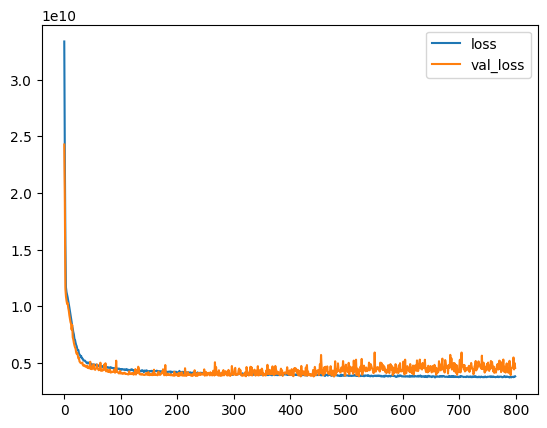

In [95]:
# let's use pandas for this (easy code)
# try to look if the model is actually training 
# => the error is going downwards
# if using validation data, you get two lines
# in this case, see if the lines follow a similar trend 
# (they don't always overlap with complex data, the trend is more important)
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [96]:
# compare the final model loss/evaluation values
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

Test data evaluation:
4552796160.0

Train data evaluation:
4261815552.0


### Based on the grapth above, the model's training and validation loss decreased rapidly during the first about 100 epochs, 
### THe model is no longer improving much after 200–250 epochs, so that is a sign that I could stop earlier training. There was no major difference between training and validation loss, meaning the model generalizes well without overfitting.

In [97]:
# get test predictions
test_predictions = model.predict(X_test)

# reshape the data for easier comparison table
test_predictions = pd.Series(test_predictions.reshape(len(y_test),))
pred_df = pd.DataFrame(np.asarray(y_test), columns=['Test True Y'])
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test True Y', 'Model Predictions']

# print the comparison table - true values vs. model predicted values
# we can nicely see here how far off our model is in some cases
pred_df

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Test True Y,Model Predictions
0,500001.0,425937.812500
1,275300.0,135002.015625
2,66800.0,71101.187500
3,328900.0,220641.765625
4,113700.0,143918.796875
...,...,...
3060,166000.0,180495.015625
3061,153400.0,138319.953125
3062,154700.0,176212.671875
3063,310100.0,243822.046875


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

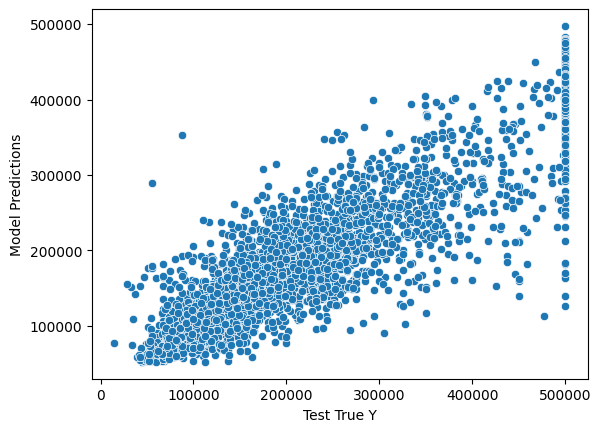

In [98]:
# these values follow a linear diagonal line = good predictions
# we basically compare the predicted values 
# to true test values and see the differences
sns.scatterplot(x='Test True Y', y='Model Predictions', data=pred_df)

In [99]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, test_predictions), 2), "$")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, test_predictions), 2), "$^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, test_predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, test_predictions), 2))

# Explained Variance Score => 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
# high variance score = model is a good fit for the data 
# low variance score = model is not a good fit for the data
# the higher the score, the model is more able to explain the variation in the data
# if score is low, we might need more and better data
print("\nExplained variance score:")
print(round(metrics.explained_variance_score(y_test, test_predictions), 2))

MAE
46196.47 $

MSE
4552795945.65 $^2

RMSE:
67474.41 $

R-squared:
0.66

Explained variance score:
0.73


C:\Users\svetl\AppData\Local\Temp\ipykernel_7172\3124900743.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - test_predictions))


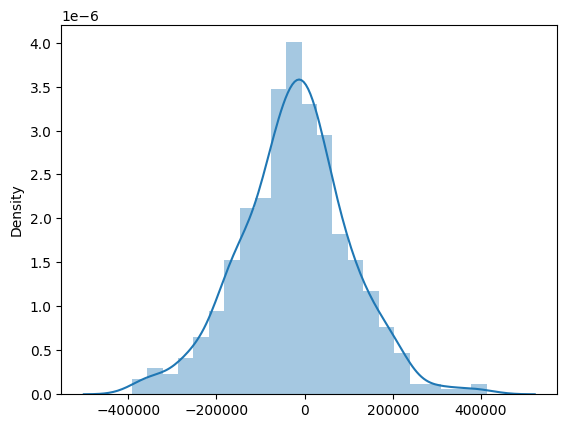

In [100]:
# if the prediction distribution are far from normal distribution
# then the model is not probably good enough
# distplot is deprecating in future pandas-version
# unfortunately, there's no exact alternative to do this plot at the moment
sns.distplot((y_test - test_predictions))
plt.show()
plt.close()

## Trying the model in practice with new imaginary house

In [101]:
# just to see what kind of values are usually in the dataset
# so we can test with the tester_row
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1


In [102]:
# example row for testing
print(X.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY']


In [103]:
# let's try with some new imaginary data

tester_row = {
    'longitude': -122.22, 
    'latitude': 37.86, 
    'housing_median_age': 41.0, 
    'total_rooms': 880.0, 
    'total_bedrooms': 129.0,
    'population': 322.0, 
    'households': 126.0	, 
    'median_income': 8.3252, 
    'ocean_proximity_<1H OCEAN': 0,
    'ocean_proximity_INLAND': 0,
    'ocean_proximity_ISLAND': 0,
    'ocean_proximity_NEAR BAY': 1,
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])

In [104]:
# get the prediction from the model and print out the result
result = model.predict(tester_row)[0]

print()
print(f"Estimated house price with this example:")
print(f"$ {round(float(result[0]), 2)}")
print("----------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step

Estimated house price with this example:
$ 407610.22
----------------


#### the model undersshoots the extimation
#### the price should be $ 452600.0 -> prediction is $ 407610.22  
## SUMMARY: 
### By using input layer -16 I got this results: R-squared: 0.67, prediction price is $ 377918.16